# Corn in Kenya: Machine Learning in Crop Classification
Mark Jerome  
April 19, 2026
## Mod-3 Do not normalize raw data, change learning rate to 1e-4, and increase epochs to 40

---


# Import necessary modules

In [1]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import xarray as xr
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, cohen_kappa_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

# Prepare data
### Load training data

In [2]:
# Open a NetCDF file
ds = xr.open_dataset('selected_data\cropharvest_Kenya_maize_train.nc')
print(ds)

<xarray.Dataset>
Dimensions:         (identifier: 3940, DEM-D1: 2, S1-D1: 12, S1-D2: 2, S2-D1: 12, S2-D2: 11, VI-D1: 12, VI-D2: 1, view_available: 5, dim_target: 1, weather-D1: 12, weather-D2: 2)
Coordinates:
  * identifier      (identifier) int32 2120 3410 819 2093 ... 3289 3460 1843
Dimensions without coordinates: DEM-D1, S1-D1, S1-D2, S2-D1, S2-D2, VI-D1, VI-D2, view_available, dim_target, weather-D1, weather-D2
Data variables:
    DEM             (identifier, DEM-D1) float32 ...
    S1              (identifier, S1-D1, S1-D2) float32 ...
    S2              (identifier, S2-D1, S2-D2) float32 ...
    VI              (identifier, VI-D1, VI-D2) float32 ...
    inverted_ident  (identifier, view_available) int32 ...
    target          (identifier, dim_target) int32 ...
    train_mask      (identifier) int32 ...
    weather         (identifier, weather-D1, weather-D2) float32 ...
Attributes:
    view_names:      ['S2', 'S1', 'weather', 'DEM', 'VI']
    target_names:    ['negative', 'posi

### Split validation data from training data

In [3]:
rng = np.random.default_rng(1955)
val_fraction = 0.1
input_len = len(ds.identifier)
val_size = int(val_fraction * input_len)
train_size = input_len - val_size
print(f'Input size = {input_len}, validation size = {val_size}, train size = {train_size}')

val_idx = rng.choice(input_len, size=val_size, replace=False)
train_idx = np.array(list(set(np.arange(input_len)) - set(val_idx)))

val_subset = ds.isel(identifier=val_idx)
train_subset = ds.isel(identifier=train_idx)

Input size = 3940, validation size = 394, train size = 3546


### Check stratification of training and validation data

In [4]:
t_values, t_counts = np.unique(ds.target.values, return_counts=True)
for i, t in enumerate(t_values):
    print(f'Target value {t} appears {t_counts[i]} times and is {t_counts[i]/input_len:.3f} of all samples.')

Target value 0 appears 3676 times and is 0.933 of all samples.
Target value 1 appears 264 times and is 0.067 of all samples.


In [5]:
all_strat = np.sum(ds.target.values)/input_len
train_strat = np.sum(train_subset.target.values)/train_size
val_strat = np.sum(val_subset.target.values)/val_size
print(f'Fraction of positive samples: all = {all_strat:.3f}, train = {train_strat:.3f}, val = {val_strat:.3f}')

Fraction of positive samples: all = 0.067, train = 0.067, val = 0.066


### Load test data

In [6]:
ds2 = xr.open_dataset('selected_data\cropharvest_Kenya_maize_test.nc')

### Check stratification of test data

In [7]:
t_values, t_counts = np.unique(ds2.target.values, return_counts=True)
for i, t in enumerate(t_values):
    print(f'Target value {t} appears {t_counts[i]} times and is {t_counts[i]/len(ds2.identifier):.3f} of all samples.')

Target value 0 appears 323 times and is 0.360 of all samples.
Target value 1 appears 575 times and is 0.640 of all samples.


### Define ch_data class to ease data handling

In [8]:
class ch_data():
    def __init__(self, xr_ds, name, views='all', train_ds=None):
        self.name = name
        self.data = {}
        if views == 'all':
            self.data['view_names'] = xr_ds.view_names
        else:
            self.data['view_names'] = views
        self.data['targets'] = xr_ds.target.to_numpy().flatten()
        for view_name in self.data['view_names']:
            self.data[view_name] = {}
            data = xr_ds[view_name].to_numpy()
            self.data[view_name]['data'] = data
            if name == 'Train':
                axis_tuple = tuple(range(data.ndim))
                self.data[view_name]['mean'] = np.mean(data, axis=axis_tuple[:-1], keepdims=True)
                self.data[view_name]['std'] = np.std(data, axis=axis_tuple[:-1], keepdims=True)
            else:
                self.data[view_name]['mean'] = train_ds.data[view_name]['mean']
                self.data[view_name]['std'] = train_ds.data[view_name]['std']
    def __len__(self):
        return len(self.data['targets'])
    def __getitem__(self, idx):
        views_dict = {}
        for view_name in self.data['view_names']:
            views_dict[view_name] = self.data[view_name]['data'][idx]
        target = self.data['targets'][idx]
        return views_dict, target
    def __repr__(self):
        head_str = f'Name: {self.name}\nData:\n\tViews:\n'
        view_list = []
        for view_name in self.data['view_names']:
            vl = f'\t\t{view_name:<9}: {self.data[view_name]["data"].shape}\n'
            view_list.append(vl)
        num_targets = len(self.data['targets'])
        pos_targets = sum(self.data['targets'])
        neg_targets = num_targets - pos_targets
        tail_str = f'\tTargets:\n\t\tCount: {num_targets}\n\t\tPositive: {pos_targets}\n\t\tNegative: {neg_targets}'
        return head_str+''.join(view_list)+tail_str
    def z_scale(self):
        for view_name in self.data['view_names']:
            mean = self.data[view_name]['mean']
            std = self.data[view_name]['std']
            self.data[view_name]['data'] = (self.data[view_name]['data'] - mean) / std
    def show_data_mean_std(self):
        for view_name in self.data['view_names']:
            data = self.data[view_name]['data']
            axis_tuple = tuple(range(data.ndim))
            mean = np.mean(data, axis=axis_tuple[:-1], keepdims=True)
            std = np.std(data, axis=axis_tuple[:-1], keepdims=True)
            print(f'{self.name} data view "{view_name}" columns have mean {np.round(mean, decimals=2)}')
            print(f'\t and standard deviation {np.round(std, decimals=2)}')
    def show_data_info(self):
        for view_name in self.data['view_names']:
            view_shape = self.data[view_name]['data'].shape
            view_nan = np.isnan(self.data[view_name]['data']).any()
            print(f'{self.name} data view "{view_name}" has shape {view_shape}. Missing values? {view_nan}')
    def make_tensors(self):
        X = {}
        for view_name in self.data['view_names']:
            X[view_name] = torch.from_numpy(self.data[view_name]['data'])
        y = torch.from_numpy(self.data['targets']).long()
        return X, y

### Load training, validation, and test data into ch_data instances

In [9]:
train_ds = ch_data(train_subset, 'Train')
val_ds = ch_data(val_subset, 'Validation', train_ds=train_ds)
test_ds = ch_data(ds2, 'Test', train_ds=train_ds)

In [10]:
print(train_ds)

Name: Train
Data:
	Views:
		S2       : (3546, 12, 11)
		S1       : (3546, 12, 2)
		weather  : (3546, 12, 2)
		DEM      : (3546, 2)
		VI       : (3546, 12, 1)
	Targets:
		Count: 3546
		Positive: 238
		Negative: 3308


### Show data info

In [11]:
train_ds.show_data_info()

Train data view "S2" has shape (3546, 12, 11). Missing values? False
Train data view "S1" has shape (3546, 12, 2). Missing values? False
Train data view "weather" has shape (3546, 12, 2). Missing values? False
Train data view "DEM" has shape (3546, 2). Missing values? False
Train data view "VI" has shape (3546, 12, 1). Missing values? False


In [12]:
val_ds.show_data_info()

Validation data view "S2" has shape (394, 12, 11). Missing values? False
Validation data view "S1" has shape (394, 12, 2). Missing values? False
Validation data view "weather" has shape (394, 12, 2). Missing values? False
Validation data view "DEM" has shape (394, 2). Missing values? False
Validation data view "VI" has shape (394, 12, 1). Missing values? False


In [13]:
test_ds.show_data_info()

Test data view "S2" has shape (898, 12, 11). Missing values? False
Test data view "S1" has shape (898, 12, 2). Missing values? False
Test data view "weather" has shape (898, 12, 2). Missing values? False
Test data view "DEM" has shape (898, 2). Missing values? False
Test data view "VI" has shape (898, 12, 1). Missing values? False


### Z-scale data

In [14]:
# train_ds.z_scale()
# val_ds.z_scale()
# test_ds.z_scale()

In [15]:
# Verify z_scale works properly
train_ds.show_data_mean_std()

Train data view "S2" columns have mean [[[ -12.26  -19.18 1369.75 1353.65 1372.26 1569.79 2257.24 2604.43
   2470.91 2821.9   678.19]]]
	 and standard deviation [[[   4.7     6.42  709.06  707.16  872.55  808.71  848.92  950.34
    919.64 1029.64  397.05]]]
Train data view "S1" columns have mean [[[2342.46 1576.82]]]
	 and standard deviation [[[1075.47  924.24]]]
Train data view "weather" columns have mean [[[295.91   0.  ]]]
	 and standard deviation [[[3.91 0.  ]]]
Train data view "DEM" columns have mean [[1196.38    5.59]]
	 and standard deviation [[641.86   7.81]]
Train data view "VI" columns have mean [[[0.3]]]
	 and standard deviation [[[0.21]]]


# Build model
### Define architecture of model

In [16]:
architecture = {}
for view_name in train_ds.data['view_names']:
    architecture[view_name] = {'layer_size':64,
                               'dropout':0.2,
                               'batchnorm':False,
                               'input_size':train_ds.data[view_name]['data'].shape[-1]
                              }
    if view_name == 'DEM':
        architecture[view_name]['model_type'] = 'mlp'
        architecture[view_name]['n_layers'] = 1
    else:
        architecture[view_name]['model_type'] = 'lstm'
        architecture[view_name]['n_layers'] = 2

### Define neural network layers used in main model

In [17]:
class Concatenate_(nn.Module):
    def forward(self, x): return torch.cat(x, dim=-1)

class LSTM_to_linear(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.2)
        self.linear = nn.Linear(in_features=hidden_size, out_features=hidden_size, bias=True)
        self.bn_linear = nn.BatchNorm1d(num_features=hidden_size, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    def forward(self, x):
        rnn_out, (h_n, c_n) = self.rnn(x)
        rnn_out = rnn_out[:,-1]
        linear_out = self.linear(rnn_out)
        out = self.bn_linear(linear_out)
        return out

### Define main model

In [18]:
class LSTM_feature_fusion(nn.Module):
    def __init__(self, view_info):
        super().__init__()
        self.view_names = view_info.keys()
        self.views_encoder = nn.ModuleDict()
        total_hidden_size = 0
        for view_name in self.view_names:
            input_size = view_info[view_name]['input_size']
            hidden_size = view_info[view_name]['layer_size']
            if view_info[view_name]['model_type'] == 'lstm':
                self.views_encoder[view_name] = LSTM_to_linear(input_size, hidden_size)
                total_hidden_size += hidden_size
            else:
                self.views_encoder[view_name] = nn.Sequential(
                    nn.Linear(in_features=input_size, out_features=hidden_size, bias=True),
                    nn.ReLU(),
                    nn.Dropout(p=0.2, inplace=False),
                    nn.Linear(in_features=hidden_size, out_features=hidden_size, bias=True),
                    nn.BatchNorm1d(num_features=hidden_size, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
                )
                total_hidden_size += hidden_size

        self.fusion_module = Concatenate_()

        self.predictive_model =nn.Sequential(
            nn.Linear(in_features=total_hidden_size, out_features=64, bias=True),
            nn.ReLU(),
            nn.BatchNorm1d(num_features=64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
            nn.Dropout(p=0.2, inplace=False),
            nn.Linear(in_features=64, out_features=2, bias=True),
            nn.BatchNorm1d(num_features=2, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        )
    def forward(self, views):
        model_views = self.view_names
        encoded_views = {}
        for v_name in model_views:
            encoded_views[v_name] = self.views_encoder[v_name](views[v_name])

        fused_views = self.fusion_module(list(encoded_views.values()))

        out = self.predictive_model(fused_views)

        return out

### Instantiate model and list it

In [19]:
MV_model = LSTM_feature_fusion(architecture)
print(MV_model)

LSTM_feature_fusion(
  (views_encoder): ModuleDict(
    (S2): LSTM_to_linear(
      (rnn): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.2)
      (linear): Linear(in_features=64, out_features=64, bias=True)
      (bn_linear): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    )
    (S1): LSTM_to_linear(
      (rnn): LSTM(2, 64, num_layers=2, batch_first=True, dropout=0.2)
      (linear): Linear(in_features=64, out_features=64, bias=True)
      (bn_linear): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    )
    (weather): LSTM_to_linear(
      (rnn): LSTM(2, 64, num_layers=2, batch_first=True, dropout=0.2)
      (linear): Linear(in_features=64, out_features=64, bias=True)
      (bn_linear): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    )
    (DEM): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace

In [20]:
print(f' Total learnable parameters = {sum(p.numel() for p in MV_model.parameters() if p.requires_grad):,}')

 Total learnable parameters = 246,594


### Define optimizer and loss function

In [21]:
labels = np.unique(train_ds.data['targets'])
weights = compute_class_weight(class_weight='balanced', classes=labels, y=train_ds.data['targets'])

In [22]:
optimizer = torch.optim.Adam(MV_model.parameters(), lr=1e-4, weight_decay=0)
loss_func = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    eps: 1e-08
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


# Load data to dataloader

In [23]:
batch_size = 256
train_dataloader = DataLoader(train_ds, batch_size = batch_size, shuffle=True)
X_train, y_train = train_ds.make_tensors()
X_val, y_val = val_ds.make_tensors()
X_test, y_test = test_ds.make_tensors()
data = (train_dataloader, X_train, y_train, X_val, y_val)

# Train and test

### Define training cycle

In [24]:
def training_cycle(model, loss_func, optimizer, data, n_epochs=20):
    train_dataloader, X_train, y_train, X_val, y_val = data
    train_ce_log = []
    val_ce_log = []
    least_loss = float('inf')
    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch in train_dataloader:
            y_pred_batch = model(X_batch)
            
            loss = loss_func(y_pred_batch, y_batch.long())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
        model.eval()
        with torch.no_grad():
            
            y_pred_train = model(X_train)
            train_ce = loss_func(y_pred_train, y_train)
            train_ce_log.append(train_ce)
    
            y_pred_val = model(X_val)
            val_ce = loss_func(y_pred_val, y_val)
            val_ce_log.append(val_ce)
    
            predicted_val_targets = y_pred_val.argmax(dim=1)
    
            val_f1_macro = f1_score(y_val, predicted_val_targets, average='macro')
    
            if val_ce < least_loss:
                least_loss = val_ce
                best_epoch = epoch
                best_model_state = copy.deepcopy(model.state_dict())
            
        print(f'Epoch {epoch}: Train Cross Entropy {train_ce:.4f}, Validation Cross Entropy {val_ce:.4f}, '
              f'Validation F1 Macro {val_f1_macro:.4f}')
        
    model_name = model.__class__.__name__
    
    plt.figure(figsize=(6,6))
    plt.plot(train_ce_log, 'b-', label='Training')
    plt.plot(val_ce_log, 'r-', label='Validation')
    plt.axvline(best_epoch, color='green', linestyle='--', label='minimum loss')
    
    plt.xticks(np.arange(0, n_epochs, 1.0))
    plt.xlabel('Epoch')
    plt.ylabel('Cross Entropy')
    plt.title(f'{model_name} Learning Curves')
    plt.legend()
    # plt.savefig(f'figures/{model_name}_learning_curve.jpg')
    plt.show()

    return best_model_state

Epoch 0: Train Cross Entropy 0.6710, Validation Cross Entropy 0.6712, Validation F1 Macro 0.2468
Epoch 1: Train Cross Entropy 0.6509, Validation Cross Entropy 0.6508, Validation F1 Macro 0.2550
Epoch 2: Train Cross Entropy 0.6157, Validation Cross Entropy 0.6165, Validation F1 Macro 0.2753
Epoch 3: Train Cross Entropy 0.5736, Validation Cross Entropy 0.5738, Validation F1 Macro 0.3453
Epoch 4: Train Cross Entropy 0.5478, Validation Cross Entropy 0.5472, Validation F1 Macro 0.3737
Epoch 5: Train Cross Entropy 0.5167, Validation Cross Entropy 0.5147, Validation F1 Macro 0.4258
Epoch 6: Train Cross Entropy 0.5017, Validation Cross Entropy 0.4935, Validation F1 Macro 0.4519
Epoch 7: Train Cross Entropy 0.4950, Validation Cross Entropy 0.4867, Validation F1 Macro 0.4787
Epoch 8: Train Cross Entropy 0.4967, Validation Cross Entropy 0.4892, Validation F1 Macro 0.4804
Epoch 9: Train Cross Entropy 0.4918, Validation Cross Entropy 0.4833, Validation F1 Macro 0.4838
Epoch 10: Train Cross Entropy 

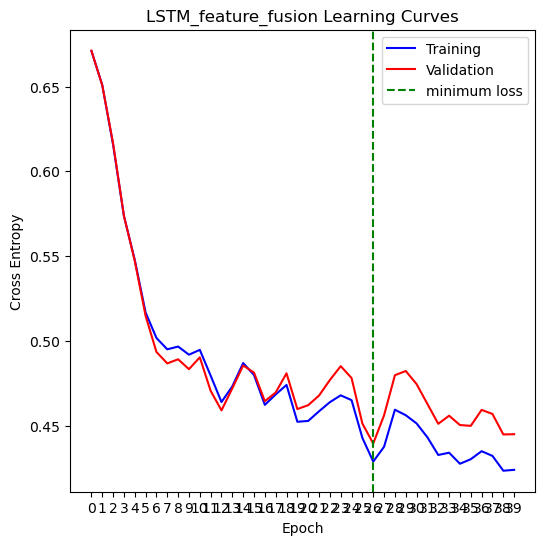

In [25]:
EPOCH = 40
best_model_state = training_cycle(MV_model, loss_func, optimizer, data, n_epochs=EPOCH)

### Define test output metrics

In [26]:
def test_metrics(model, best_model_state, X_test, y_test):
    model.load_state_dict(best_model_state)
    model.eval()
    y_pred_test = model(X_test)
    predicted_test_targets = y_pred_test.argmax(dim=1)
    
    test_average_accuracy = balanced_accuracy_score(y_test, predicted_test_targets)
    test_kappa = cohen_kappa_score(y_test, predicted_test_targets)
    test_f1_macro = f1_score(y_test, predicted_test_targets, average='macro')
    test_cm = confusion_matrix(y_test, predicted_test_targets)
    
    print()
    print(f'Test Average Accuracy {test_average_accuracy*100:.4f}, Test Kappa {test_kappa*100:.4f}, Test F1 Macro {test_f1_macro*100:.4f}')
    print()

    model_name = model.__class__.__name__
    ConfusionMatrixDisplay(test_cm).plot()
    plt.title(f'Confusion Matrix for {model_name} Test Data')
    # plt.savefig(f'figures/{model_name}_test_cm.jpg')
    plt.show()


Test Average Accuracy 66.6992, Test Kappa 39.0088, Test F1 Macro 67.1857



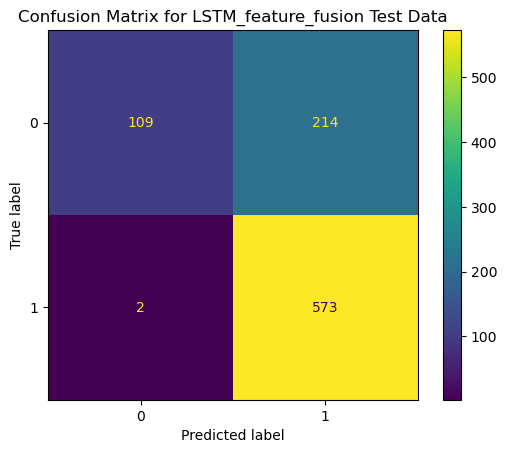

In [27]:
test_metrics(MV_model, best_model_state, X_test, y_test)

# Second model: Single view using S2 only

In [28]:
single_view = ['S2']

### Load training, validation, and test data into ch_data instances

In [29]:
train_ds = ch_data(train_subset, 'Train', views=single_view)
val_ds = ch_data(val_subset, 'Validation', views=single_view, train_ds=train_ds)
test_ds = ch_data(ds2, 'Test', views=single_view, train_ds=train_ds)

In [30]:
print(train_ds)

Name: Train
Data:
	Views:
		S2       : (3546, 12, 11)
	Targets:
		Count: 3546
		Positive: 238
		Negative: 3308


### Z-scale data

In [31]:
# train_ds.z_scale()
# val_ds.z_scale()
# test_ds.z_scale()

### Build second model

In [32]:
class single_view(nn.Module):
    def __init__(self):
        super().__init__()
        input_size = 11
        hidden_size =64
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.2)
        self.predictive_model =nn.Sequential(
            nn.Linear(in_features=hidden_size, out_features=hidden_size, bias=True),
            nn.BatchNorm1d(num_features=hidden_size, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True),
            nn.Linear(in_features=hidden_size, out_features=64, bias=True),
            nn.ReLU(),
            nn.BatchNorm1d(num_features=64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
            nn.Dropout(p=0.2, inplace=False),
            nn.Linear(in_features=64, out_features=2, bias=True),
            nn.BatchNorm1d(num_features=2, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        )
    def forward(self, x):
        view = x['S2']
        rnn_out, (h_n, c_n) = self.rnn(view)
        rnn_out = rnn_out[:,-1]
        out = self.predictive_model(rnn_out)
        return out

In [33]:
SV_model = single_view()
print(SV_model)

single_view(
  (rnn): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.2)
  (predictive_model): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
    (7): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  )
)


In [34]:
print(f' Total learnable parameters = {sum(p.numel() for p in SV_model.parameters() if p.requires_grad):,}')

 Total learnable parameters = 61,570


### Define optimizer and loss function

In [35]:
labels2 = np.unique(train_ds.data['targets'])
weights2 = compute_class_weight(class_weight='balanced', classes=labels2, y=train_ds.data['targets'])

In [36]:
optimizer2 = torch.optim.Adam(SV_model.parameters(), lr=1e-4, weight_decay=0)
loss_func2 = nn.CrossEntropyLoss(weight=torch.tensor(weights2, dtype=torch.float))
print(optimizer2)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    eps: 1e-08
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


# Load data to dataloader

In [37]:
batch_size = 256
train_dataloader = DataLoader(train_ds, batch_size = batch_size, shuffle=True)
X_train, y_train = train_ds.make_tensors()
X_val, y_val = val_ds.make_tensors()
X_test, y_test = test_ds.make_tensors()
data = (train_dataloader, X_train, y_train, X_val, y_val)

# Train and test

Epoch 0: Train Cross Entropy 0.6929, Validation Cross Entropy 0.6960, Validation F1 Macro 0.0619
Epoch 1: Train Cross Entropy 0.6854, Validation Cross Entropy 0.6934, Validation F1 Macro 0.0816
Epoch 2: Train Cross Entropy 0.6596, Validation Cross Entropy 0.6765, Validation F1 Macro 0.2146
Epoch 3: Train Cross Entropy 0.6150, Validation Cross Entropy 0.6380, Validation F1 Macro 0.3489
Epoch 4: Train Cross Entropy 0.5798, Validation Cross Entropy 0.6162, Validation F1 Macro 0.3932
Epoch 5: Train Cross Entropy 0.5626, Validation Cross Entropy 0.5963, Validation F1 Macro 0.4330
Epoch 6: Train Cross Entropy 0.5519, Validation Cross Entropy 0.5744, Validation F1 Macro 0.4643
Epoch 7: Train Cross Entropy 0.5396, Validation Cross Entropy 0.5745, Validation F1 Macro 0.4569
Epoch 8: Train Cross Entropy 0.5414, Validation Cross Entropy 0.5776, Validation F1 Macro 0.4435
Epoch 9: Train Cross Entropy 0.5370, Validation Cross Entropy 0.5678, Validation F1 Macro 0.4435
Epoch 10: Train Cross Entropy 

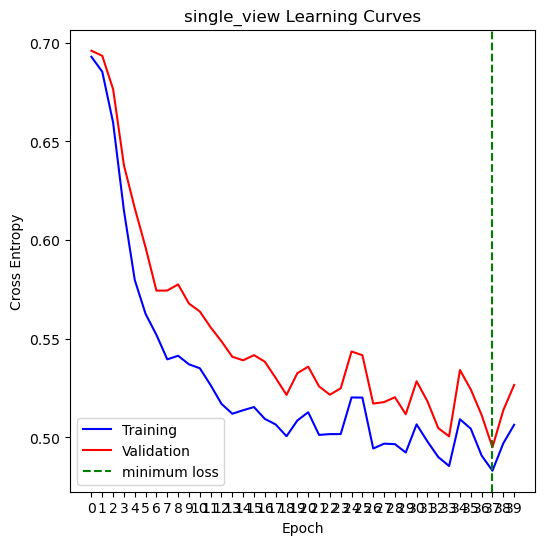

In [38]:
EPOCH = 40
best_model_state = training_cycle(SV_model, loss_func2, optimizer2, data, n_epochs=EPOCH)


Test Average Accuracy 68.5567, Test Kappa 42.9397, Test F1 Macro 69.5745



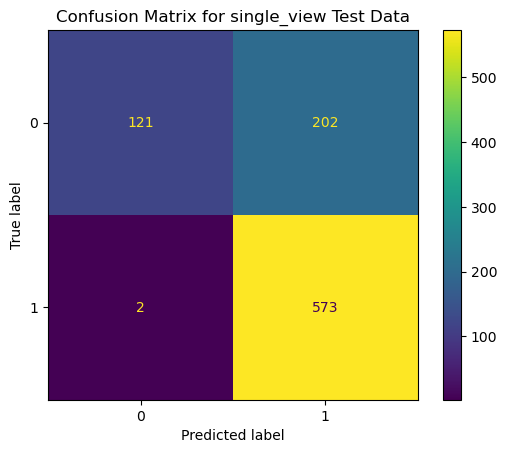

In [39]:
test_metrics(SV_model, best_model_state, X_test, y_test)